# Hyperspectral & Sentinel-2 Analysis Notebook

**Tasks covered:**
1. False-colour composites from the airborne BSQ/HDR data cube
2. Water quality indices from airborne data (Chl-a, DOC, Turbidity, NDWI)
3. Download Sentinel-2 L2A data close to the airborne acquisition date via **openEO / CDSE** (free)
4. Calculate the same water quality indices from Sentinel-2 and compare
5. Spectral library visualisation (buildings, forest, field, grass, water)

**Airborne acquisition date:** 17 June 2025  
**Spectral library:** 5 classes × 456 bands (414–2499 nm)  
**Sentinel-2 access:** openEO + Copernicus Data Space (free account at https://dataspace.copernicus.eu)

---

## 0. Install Dependencies
Run once, then restart the kernel.

In [1]:
# !pip install spectral numpy matplotlib pandas rasterio scipy openeo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import spectral.io.envi as envi
import rasterio
from rasterio.crs import CRS
import openeo
from pathlib import Path
from datetime import datetime, timedelta
from scipy.signal import savgol_filter
import os, warnings
from typing import Optional
from dataclasses import dataclass
warnings.filterwarnings('ignore')

print('All imports OK.')

All imports OK.


---
## 1. Configuration

In [38]:
# ── AIRBORNE DATA ─────────────────────────────────────────────────────────────
HDR_FILE = r'data/obrazy_lotnicze/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr'   # <── update
BSQ_FILE = r'data/obrazy_lotnicze/221000_Odra_HS_Blok_A_015_VS_join_atm.bsq'   # <── update

# ── SPECTRAL LIBRARY  (merged from individual class CSVs) ─────────────────────
# Columns: Wavelength, buildings, forest, field, grass, water
SPECTRAL_LIBRARY_CSV = r'data/spectral_library_updated.csv'   # place next to this notebook

# ── ACQUISITION DATE ──────────────────────────────────────────────────────────
AIRBORNE_DATE    = '2025-06-17'
DATE_WINDOW_DAYS = 5   # search Sentinel-2 within ±N days

# ── AREA OF INTEREST  (WGS-84 bounding box) ───────────────────────────────────
AOI_WEST  = 18.241253
AOI_SOUTH = 50.336258
AOI_EAST  = 18.29361
AOI_NORTH = 50.360795

# ── OUTPUT ────────────────────────────────────────────────────────────────────
OUTPUT_DIR = './results'
S2_DIR     = './sentinel2_data'
for d in [OUTPUT_DIR, S2_DIR]:
    os.makedirs(d, exist_ok=True)

# Nechad 2010 turbidity coefficients (665 nm channel)
A_T, C_T = 228.1, 0.1641

print(f'Airborne date  : {AIRBORNE_DATE}')
print(f'Search window  : ±{DATE_WINDOW_DAYS} days')
print(f'AOI            : W={AOI_WEST} S={AOI_SOUTH} E={AOI_EAST} N={AOI_NORTH}')

Airborne date  : 2025-06-17
Search window  : ±5 days
AOI            : W=18.241253 S=50.336258 E=18.29361 N=50.360795


---
## 2. Spectral Library — Load & Visualise
Five land-cover classes collected from the airborne data cube:  
**buildings · forest · field · grass · water**  
456 bands, 414 – 2499 nm

In [4]:
lib = pd.read_csv(SPECTRAL_LIBRARY_CSV)
WL_COL     = 'Wavelength'
CLASS_COLS = [c for c in lib.columns if c != WL_COL]
wl         = lib[WL_COL].values

print(f'Spectral library: {len(lib)} bands  |  {len(CLASS_COLS)} classes: {CLASS_COLS}')
print(f'Wavelength range: {wl.min():.1f} – {wl.max():.1f} nm')
lib.describe().round(4)

Spectral library: 456 bands  |  5 classes: ['buildings', 'forest', 'field', 'grass', 'water']
Wavelength range: 414.1 – 2498.9 nm


,Wavelength,buildings,forest,field,grass,water
count,456.0000,456.0000,456.0000,456.0000,456.0000,456.0000
mean,1336.1783,0.1725,0.1481,0.1757,0.1706,0.0297
std,623.7994,0.0812,0.1356,0.0527,0.1426,0.0391
min,414.1300,0.0504,0.0116,0.0403,0.0145,0.0000
25%,777.7400,0.0980,0.0279,0.1502,0.0483,0.0059
50%,1261.1700,0.1811,0.0803,0.1874,0.0946,0.0114
75%,1880.0300,0.2299,0.2862,0.2112,0.3389,0.0515
max,2498.8900,0.9464,0.5532,0.2757,0.4248,0.4910


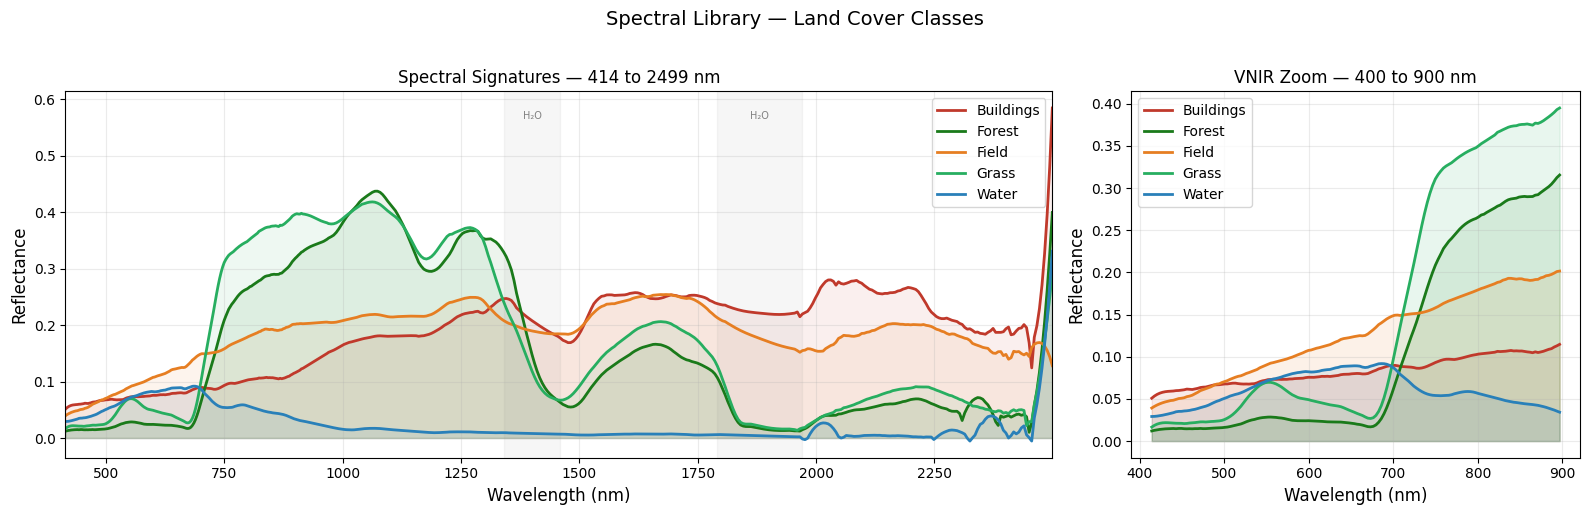

Saved -> spectral_library.png


In [5]:
# Colour palette consistent across all plots
CLASS_COLORS = {
    'buildings': '#c0392b',
    'forest':    '#1a7a1a',
    'field':     '#e67e22',
    'grass':     '#27ae60',
    'water':     '#2980b9',
}

def smooth(arr, win=15):
    if len(arr) > win:
        w = win if win % 2 == 1 else win - 1
        return savgol_filter(arr, w, 3)
    return arr

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [2.2, 1]})

# ── Left: full spectral signatures ───────────────────────────────────────────
ax = axes[0]
for cls in CLASS_COLS:
    ref = lib[cls].values.astype(float)
    smt = smooth(ref)
    c   = CLASS_COLORS[cls]
    ax.plot(wl, smt, color=c, lw=2, label=cls.capitalize())
    ax.fill_between(wl, smt, alpha=0.08, color=c)

# Shade common atmospheric absorption windows
for lo, hi, lbl in [(1340, 1460, 'H₂O'), (1790, 1970, 'H₂O')]:
    ax.axvspan(lo, hi, alpha=0.07, color='grey')
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.92, lbl,
            ha='center', fontsize=7, color='grey')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('Spectral Signatures — 414 to 2499 nm', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.25)
ax.set_xlim(wl.min(), wl.max())

# ── Right: visible/NIR zoom (400–900 nm) ──────────────────────────────────────
ax2 = axes[1]
mask_vnir = (wl >= 400) & (wl <= 900)
for cls in CLASS_COLS:
    ref  = lib[cls].values.astype(float)
    smt  = smooth(ref)
    c    = CLASS_COLORS[cls]
    ax2.plot(wl[mask_vnir], smt[mask_vnir], color=c, lw=2, label=cls.capitalize())
    ax2.fill_between(wl[mask_vnir], smt[mask_vnir], alpha=0.1, color=c)

ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Reflectance', fontsize=12)
ax2.set_title('VNIR Zoom — 400 to 900 nm', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.25)

plt.suptitle('Spectral Library — Land Cover Classes', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/spectral_library.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> spectral_library.png')

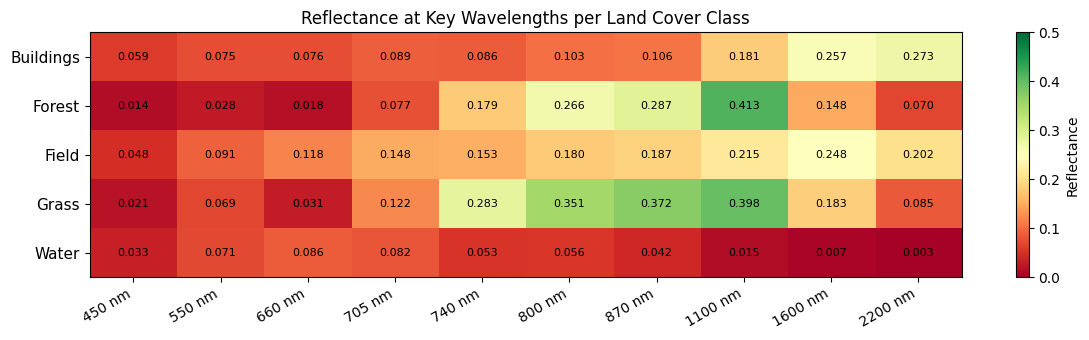

Saved -> spectral_heatmap.png


In [6]:
# Band-ratio heatmap — how separable are the classes at key wavelengths?
KEY_NM = [450, 550, 660, 705, 740, 800, 870, 1100, 1600, 2200]

def nearest_refl(cls, target_nm):
    idx = np.argmin(np.abs(wl - target_nm))
    return lib[cls].values[idx]

heatmap_data = pd.DataFrame(
    {f'{nm} nm': [nearest_refl(c, nm) for c in CLASS_COLS] for nm in KEY_NM},
    index=[c.capitalize() for c in CLASS_COLS]
)

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='Reflectance')
ax.set_xticks(range(len(KEY_NM)))
ax.set_xticklabels([f'{n} nm' for n in KEY_NM], rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(CLASS_COLS)))
ax.set_yticklabels([c.capitalize() for c in CLASS_COLS], fontsize=11)
for r in range(len(CLASS_COLS)):
    for c in range(len(KEY_NM)):
        ax.text(c, r, f'{heatmap_data.values[r, c]:.3f}',
                ha='center', va='center', fontsize=8)
ax.set_title('Reflectance at Key Wavelengths per Land Cover Class', fontsize=12)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/spectral_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> spectral_heatmap.png')

---
## 3. Load Airborne Hyperspectral Cube (BSQ / HDR)

In [7]:
img  = envi.open(HDR_FILE, BSQ_FILE)
data = img.load()   # (rows, cols, bands)

cube_wl = np.array(img.metadata['wavelength'], dtype=float)
nrows, ncols, nbands = data.shape

print(f'Cube shape      : {nrows} x {ncols} x {nbands}')
print(f'Wavelength range: {cube_wl.min():.1f} – {cube_wl.max():.1f} nm')

Cube shape      : 2838 x 3862 x 456
Wavelength range: 414.1 – 2498.9 nm


In [8]:
def find_band(wl_arr, target, tol=15):
    idx = int(np.argmin(np.abs(wl_arr - target)))
    if abs(wl_arr[idx] - target) > tol:
        raise ValueError(f'No band within {tol} nm of {target} nm '
                         f'(closest: {wl_arr[idx]:.1f} nm)')
    return idx

def get_band(data, wl_arr, nm):
    return data[:, :, find_band(wl_arr, nm)].astype(np.float32)

def stretch(band, pct=(2, 98)):
    b = band.astype(float)
    lo, hi = np.nanpercentile(b, pct)
    return np.clip((b - lo) / (hi - lo + 1e-9), 0, 1)

def save_tif(arr, path, transform, crs):
    with rasterio.open(
        path, 'w', driver='GTiff',
        height=arr.shape[0], width=arr.shape[1],
        count=1, dtype='float32',
        crs=crs, transform=transform, nodata=np.nan
    ) as dst:
        dst.write(arr.astype(np.float32), 1)

print('Utilities ready.')

Utilities ready.


---
## 4. False-Colour Composites — Airborne Data

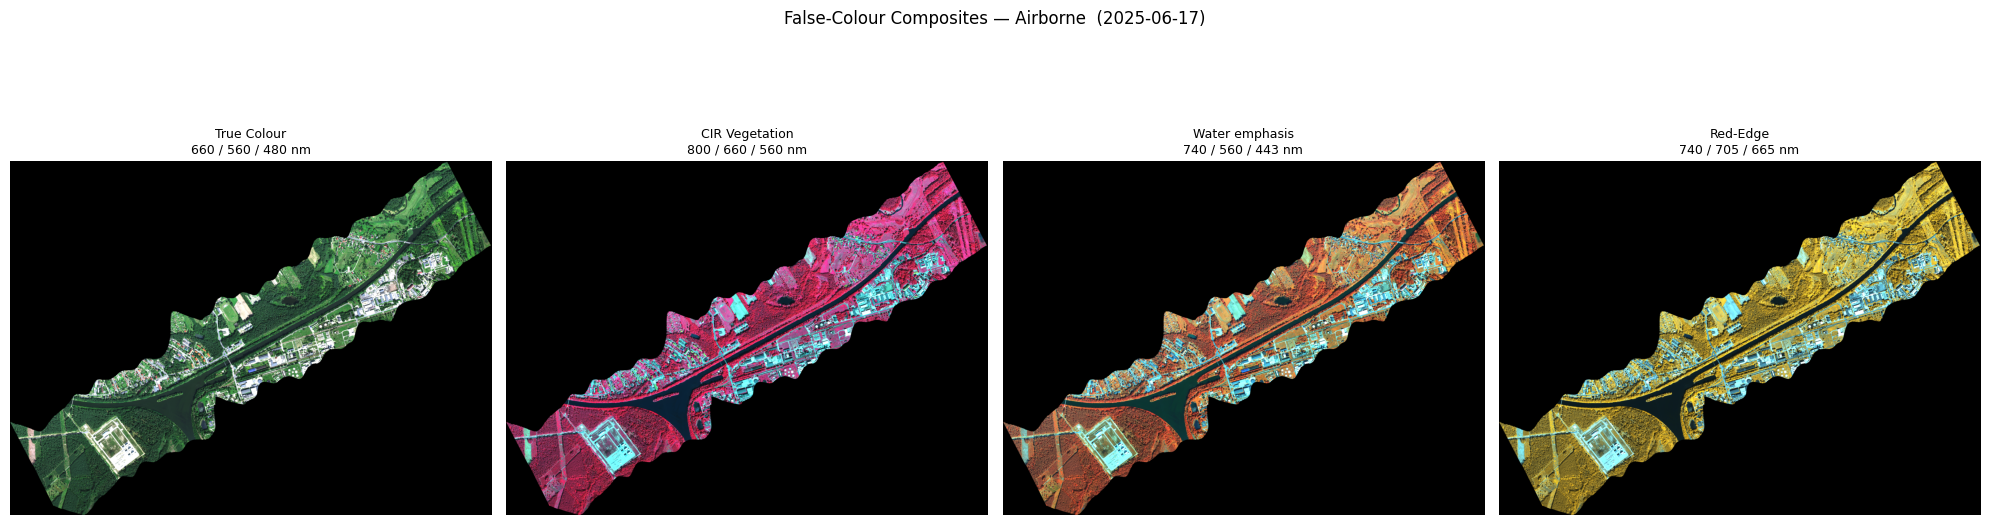

Saved -> false_colour_airborne.png


In [9]:
COMPOSITES = {
    'True Colour\n660 / 560 / 480 nm':   (660, 560, 480),
    'CIR Vegetation\n800 / 660 / 560 nm': (800, 660, 560),
    'Water emphasis\n740 / 560 / 443 nm': (740, 560, 443),
    'Red-Edge\n740 / 705 / 665 nm':       (740, 705, 665),
}

fig, axes = plt.subplots(1, len(COMPOSITES), figsize=(5 * len(COMPOSITES), 6))
for ax, (title, (r, g, b)) in zip(axes, COMPOSITES.items()):
    try:
        rgb = np.dstack([
            stretch(get_band(data, cube_wl, r)),
            stretch(get_band(data, cube_wl, g)),
            stretch(get_band(data, cube_wl, b)),
        ])
        ax.imshow(rgb)
        ax.set_title(title, fontsize=9)
    except ValueError as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes,
                ha='center', va='center', fontsize=7, color='red')
        ax.set_title(f'{title}\n[skipped]', fontsize=8)
    ax.axis('off')

plt.suptitle(f'False-Colour Composites — Airborne  ({AIRBORNE_DATE})',
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/false_colour_airborne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> false_colour_airborne.png')

---
## 5. Water Quality Indices — Airborne Data

| Index | Formula | Reference |
|---|---|---|
| **Chl-a** (Gitelson 3-band) | (1/R₆₆₅ − 1/R₇₀₅) · R₇₄₀ | Gitelson et al. 2008 |
| **DOC** proxy | R₄₄₃ / R₅₆₀ | Kutser et al. 2005 |
| **Turbidity** (Nechad 2010) | A · ρ₆₆₅ / (1 − ρ₆₆₅/C) | Nechad et al. 2010 |
| **NDWI** | (R₅₆₀ − R₈₆₀) / (R₅₆₀ + R₈₆₀) | McFeeters 1996 |

In [10]:
AIR = {nm: get_band(data, cube_wl, nm) for nm in [443, 560, 665, 705, 740, 860]}

with np.errstate(divide='ignore', invalid='ignore'):
    ndwi_air  = np.where((AIR[560]+AIR[860])!=0,
                         (AIR[560]-AIR[860])/(AIR[560]+AIR[860]), np.nan)
    water_air = ndwi_air > 0

    chla_air  = np.where((AIR[665]>0)&(AIR[705]>0),
                         (1/AIR[665]-1/AIR[705])*AIR[740], np.nan)
    doc_air   = np.where(AIR[560]>0, AIR[443]/AIR[560], np.nan)

    rho       = AIR[665]/np.pi
    turb_air  = np.where((1-rho/C_T)!=0, A_T*rho/(1-rho/C_T), np.nan)

chla_air_w = np.where(water_air, chla_air, np.nan)
doc_air_w  = np.where(water_air, doc_air,  np.nan)
turb_air_w = np.where(water_air, turb_air, np.nan)

for name, arr in [('Chl-a', chla_air_w), ('DOC', doc_air_w), ('Turb', turb_air_w)]:
    print(f'{name:6s}  mean={np.nanmean(arr):.4f}  '
          f'std={np.nanstd(arr):.4f}  '
          f'min={np.nanmin(arr):.4f}  max={np.nanmax(arr):.4f}')

Chl-a   mean=0.0809  std=0.2017  min=-2.0874  max=0.8791
DOC     mean=0.6569  std=0.1113  min=0.0773  max=1.9875
Turb    mean=0.3021  std=1119.0488  min=-298512.5000  max=142493.5625


In [11]:
# Read spatial reference from ENVI header
try:
    mi      = img.metadata['map info']   # already a list, no .split() needed
    x0, y0  = float(mi[3]), float(mi[4])
    px, py  = float(mi[5]), float(mi[6])
    air_tf  = rasterio.transform.from_origin(x0, y0, px, py)
    air_crs = CRS.from_epsg(2178)        # ETRS89 / Poland CS2000 Zone 6
    print(f'Spatial ref: EPSG:2178, origin=({x0}, {y0}), pixel={px}x{py} m')
except Exception as e:
    print(f'[WARNING] {e}')
    air_tf  = rasterio.transform.from_origin(0, nrows, 1, 1)
    air_crs = CRS.from_epsg(4326)

chla_air_w = np.squeeze(chla_air_w)
doc_air_w  = np.squeeze(doc_air_w)
turb_air_w = np.squeeze(turb_air_w)
ndwi_air   = np.squeeze(ndwi_air)
water_air  = np.squeeze(water_air)

save_tif(chla_air_w, f'{OUTPUT_DIR}/chla_airborne.tif',  air_tf, air_crs)
save_tif(doc_air_w,  f'{OUTPUT_DIR}/doc_airborne.tif',   air_tf, air_crs)
save_tif(turb_air_w, f'{OUTPUT_DIR}/turb_airborne.tif',  air_tf, air_crs)
save_tif(ndwi_air,   f'{OUTPUT_DIR}/ndwi_airborne.tif',  air_tf, air_crs)
print('Airborne index GeoTIFFs saved.')

Spatial ref: EPSG:2178, origin=(6517216.0, 5581457.0), pixel=1.0x1.0 m
Airborne index GeoTIFFs saved.


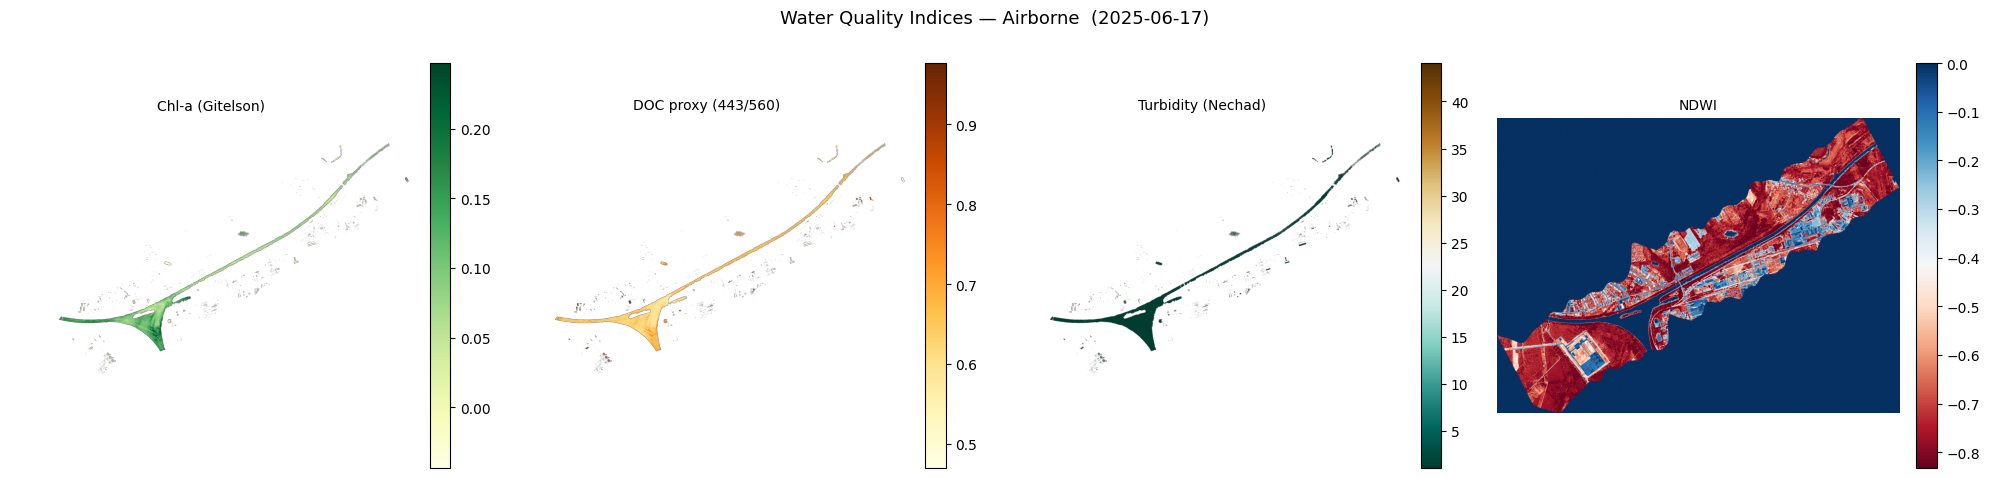

Saved -> water_quality_airborne.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, arr, cmap) in zip(axes, [
    ('Chl-a (Gitelson)',    chla_air_w, 'YlGn'),
    ('DOC proxy (443/560)', doc_air_w,  'YlOrBr'),
    ('Turbidity (Nechad)',  turb_air_w, 'BrBG_r'),
    ('NDWI',                ndwi_air,   'RdBu'),
]):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10); ax.axis('off')

plt.suptitle(f'Water Quality Indices — Airborne  ({AIRBORNE_DATE})', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/water_quality_airborne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> water_quality_airborne.png')

---
## 6. Download Sentinel-2 via openEO / Copernicus Data Space (free)

> **Authentication note:** if `authenticate_oidc_credentials` fails,  
> the code automatically falls back to `authenticate_oidc()` (browser login).

In [13]:
import ee
ee.Authenticate()

True

In [14]:
conn = openeo.connect('https://openeo.dataspace.copernicus.eu')
conn.authenticate_oidc()
print('Connected:', conn.describe_account().get('name'))

Authenticated using refresh token.
Connected: Paweł Stano


In [15]:
acq    = datetime.strptime(AIRBORNE_DATE, '%Y-%m-%d')
d_from = (acq - timedelta(days=DATE_WINDOW_DAYS)).strftime('%Y-%m-%d')
d_to   = (acq + timedelta(days=DATE_WINDOW_DAYS)).strftime('%Y-%m-%d')
print(f'Sentinel-2 temporal window: {d_from}  to  {d_to}')

extent   = dict(west=AOI_WEST, south=AOI_SOUTH,
                east=AOI_EAST, north=AOI_NORTH, crs='EPSG:4326')
S2_BANDS = ['B02','B03','B04','B05','B06','B07','B8A','B11','SCL']

s2_cube = conn.load_collection(
    'SENTINEL2_L2A',
    spatial_extent  = extent,
    temporal_extent = [d_from, d_to],
    bands           = S2_BANDS,
    max_cloud_cover = 20,
)
print(f'Collection loaded. Bands: {S2_BANDS}')

Sentinel-2 temporal window: 2025-06-12  to  2025-06-22
Collection loaded. Bands: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B8A', 'B11', 'SCL']


In [16]:
# Cloud mask via SCL: keep 4=veg, 5=bare soil, 6=water
scl     = s2_cube.band('SCL')
mask    = ~((scl == 4) | (scl == 5) | (scl == 6))
s2_mc   = s2_cube.mask(mask)
s2_comp = s2_mc.reduce_dimension(dimension='t', reducer='median')

S2_OUT = f'{S2_DIR}/s2_composite.tif'
print('Submitting openEO job... (1–5 min depending on AOI size)')
s2_comp.download(S2_OUT, format='GTiff')
print(f'Done -> {S2_OUT}')

Submitting openEO job... (1–5 min depending on AOI size)
Done -> ./sentinel2_data/s2_composite.tif


---
## 7. Load & Display Sentinel-2 Composite

In [17]:
BAND_IDX = {b: i + 1 for i, b in enumerate(S2_BANDS)}

with rasterio.open(S2_OUT) as src:
    s2_tf  = src.transform
    s2_crs = src.crs
    s2_all = src.read().astype(np.float32)

s2_refl = s2_all.copy()
s2_refl[:-1] /= 10000.0   # DN -> reflectance (skip SCL band)

def s2b(band_name):
    arr = s2_refl[BAND_IDX[band_name] - 1].copy()
    arr[arr <= 0] = np.nan
    return arr

S2 = {b: s2b(b) for b in ['B02','B03','B04','B05','B06','B07','B8A','B11']}
print('S2 bands loaded. Shape:', S2['B04'].shape)
print(f'CRS: {s2_crs}  |  pixel: {s2_tf.a:.0f} m')

S2 bands loaded. Shape: (287, 383)
CRS: EPSG:32634  |  pixel: 10 m


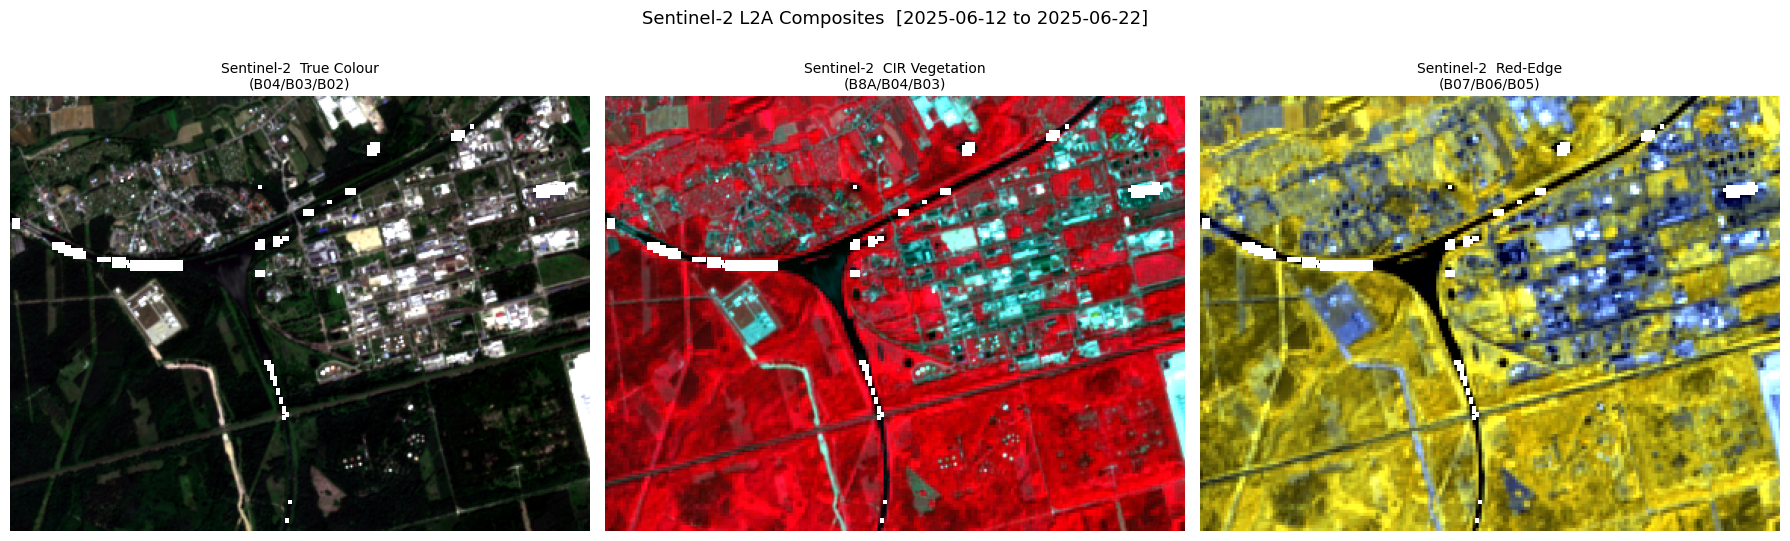

Saved -> false_colour_s2.png


In [18]:
S2_COMPOSITES = {
    'True Colour\n(B04/B03/B02)':    [S2['B04'], S2['B03'], S2['B02']],
    'CIR Vegetation\n(B8A/B04/B03)': [S2['B8A'], S2['B04'], S2['B03']],
    'Red-Edge\n(B07/B06/B05)':       [S2['B07'], S2['B06'], S2['B05']],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, bands) in zip(axes, S2_COMPOSITES.items()):
    ax.imshow(np.dstack([stretch(b) for b in bands]))
    ax.set_title(f'Sentinel-2  {title}', fontsize=10)
    ax.axis('off')
plt.suptitle(f'Sentinel-2 L2A Composites  [{d_from} to {d_to}]', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/false_colour_s2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> false_colour_s2.png')

---
## 8. Water Quality Indices — Sentinel-2

| Airborne band | S2 equivalent | Centre wavelength |
|---|---|---|
| 443 nm | B02 | 490 nm |
| 560 nm | B03 | 560 nm |
| 665 nm | B04 | 665 nm |
| 705 nm | B05 | 705 nm |
| 740 nm | B06 | 740 nm |
| 860 nm | B8A | 865 nm |

In [19]:
with np.errstate(divide='ignore', invalid='ignore'):
    ndwi_s2  = np.where((S2['B03']+S2['B8A'])!=0,
                        (S2['B03']-S2['B8A'])/(S2['B03']+S2['B8A']), np.nan)
    water_s2 = ndwi_s2 > 0

    chla_s2  = np.where((S2['B04']>0)&(S2['B05']>0),
                        (1/S2['B04']-1/S2['B05'])*S2['B06'], np.nan)
    doc_s2   = np.where(S2['B03']>0, S2['B02']/S2['B03'], np.nan)

    rho_s2   = S2['B04']/np.pi
    turb_s2  = np.where((1-rho_s2/C_T)!=0,
                        A_T*rho_s2/(1-rho_s2/C_T), np.nan)

chla_s2_w = np.where(water_s2, chla_s2, np.nan)
doc_s2_w  = np.where(water_s2, doc_s2,  np.nan)
turb_s2_w = np.where(water_s2, turb_s2, np.nan)

save_tif(chla_s2_w, f'{OUTPUT_DIR}/chla_s2.tif',  s2_tf, s2_crs)
save_tif(doc_s2_w,  f'{OUTPUT_DIR}/doc_s2.tif',   s2_tf, s2_crs)
save_tif(turb_s2_w, f'{OUTPUT_DIR}/turb_s2.tif',  s2_tf, s2_crs)
save_tif(ndwi_s2,   f'{OUTPUT_DIR}/ndwi_s2.tif',  s2_tf, s2_crs)

for name, arr in [('Chl-a', chla_s2_w), ('DOC', doc_s2_w), ('Turb', turb_s2_w)]:
    print(f'{name:6s}  mean={np.nanmean(arr):.4f}  '
          f'std={np.nanstd(arr):.4f}  '
          f'min={np.nanmin(arr):.4f}  max={np.nanmax(arr):.4f}')

Chl-a   mean=0.0702  std=0.2731  min=-0.5529  max=0.8316
DOC     mean=0.8675  std=0.0749  min=0.6431  max=1.0768
Turb    mean=2.5824  std=1196.2485  min=-29073.4746  max=9933.2197


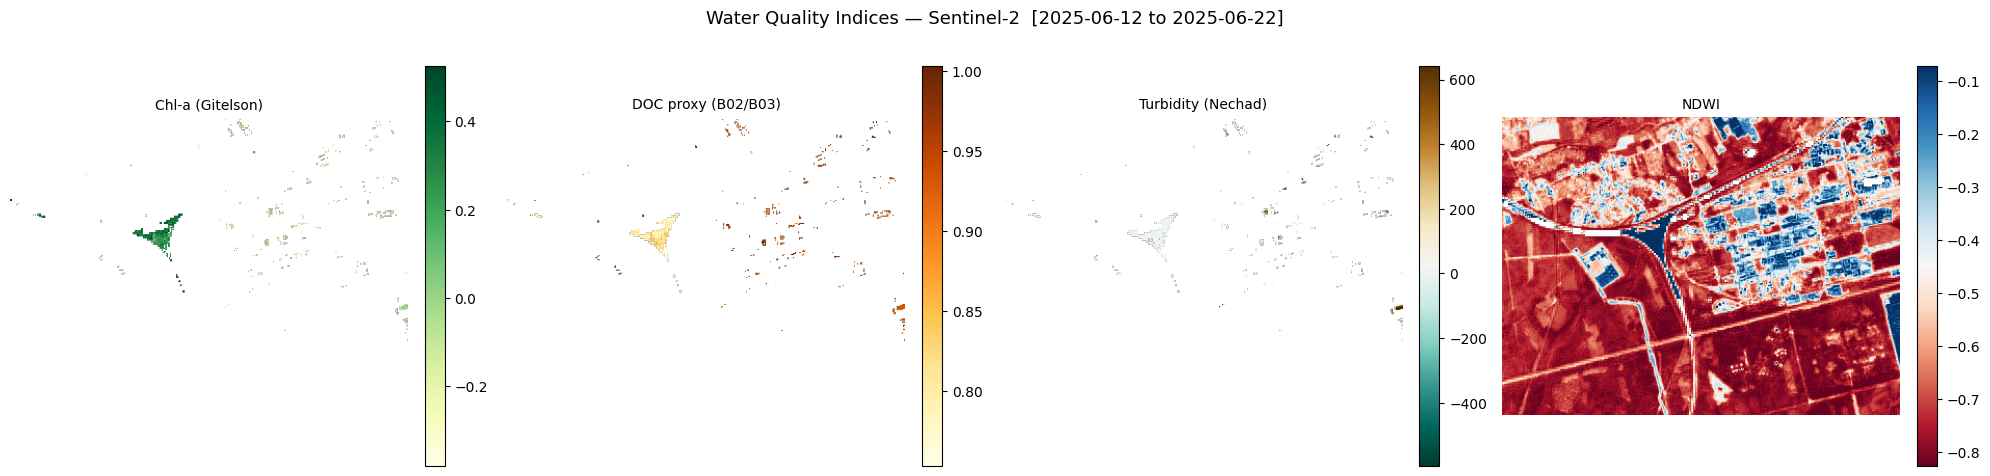

Saved -> water_quality_s2.png


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, arr, cmap) in zip(axes, [
    ('Chl-a (Gitelson)',    chla_s2_w, 'YlGn'),
    ('DOC proxy (B02/B03)', doc_s2_w,  'YlOrBr'),
    ('Turbidity (Nechad)',  turb_s2_w, 'BrBG_r'),
    ('NDWI',                ndwi_s2,   'RdBu'),
]):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Water Quality Indices — Sentinel-2  [{d_from} to {d_to}]', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/water_quality_s2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> water_quality_s2.png')

---
## 9. Comparison: Airborne vs Sentinel-2

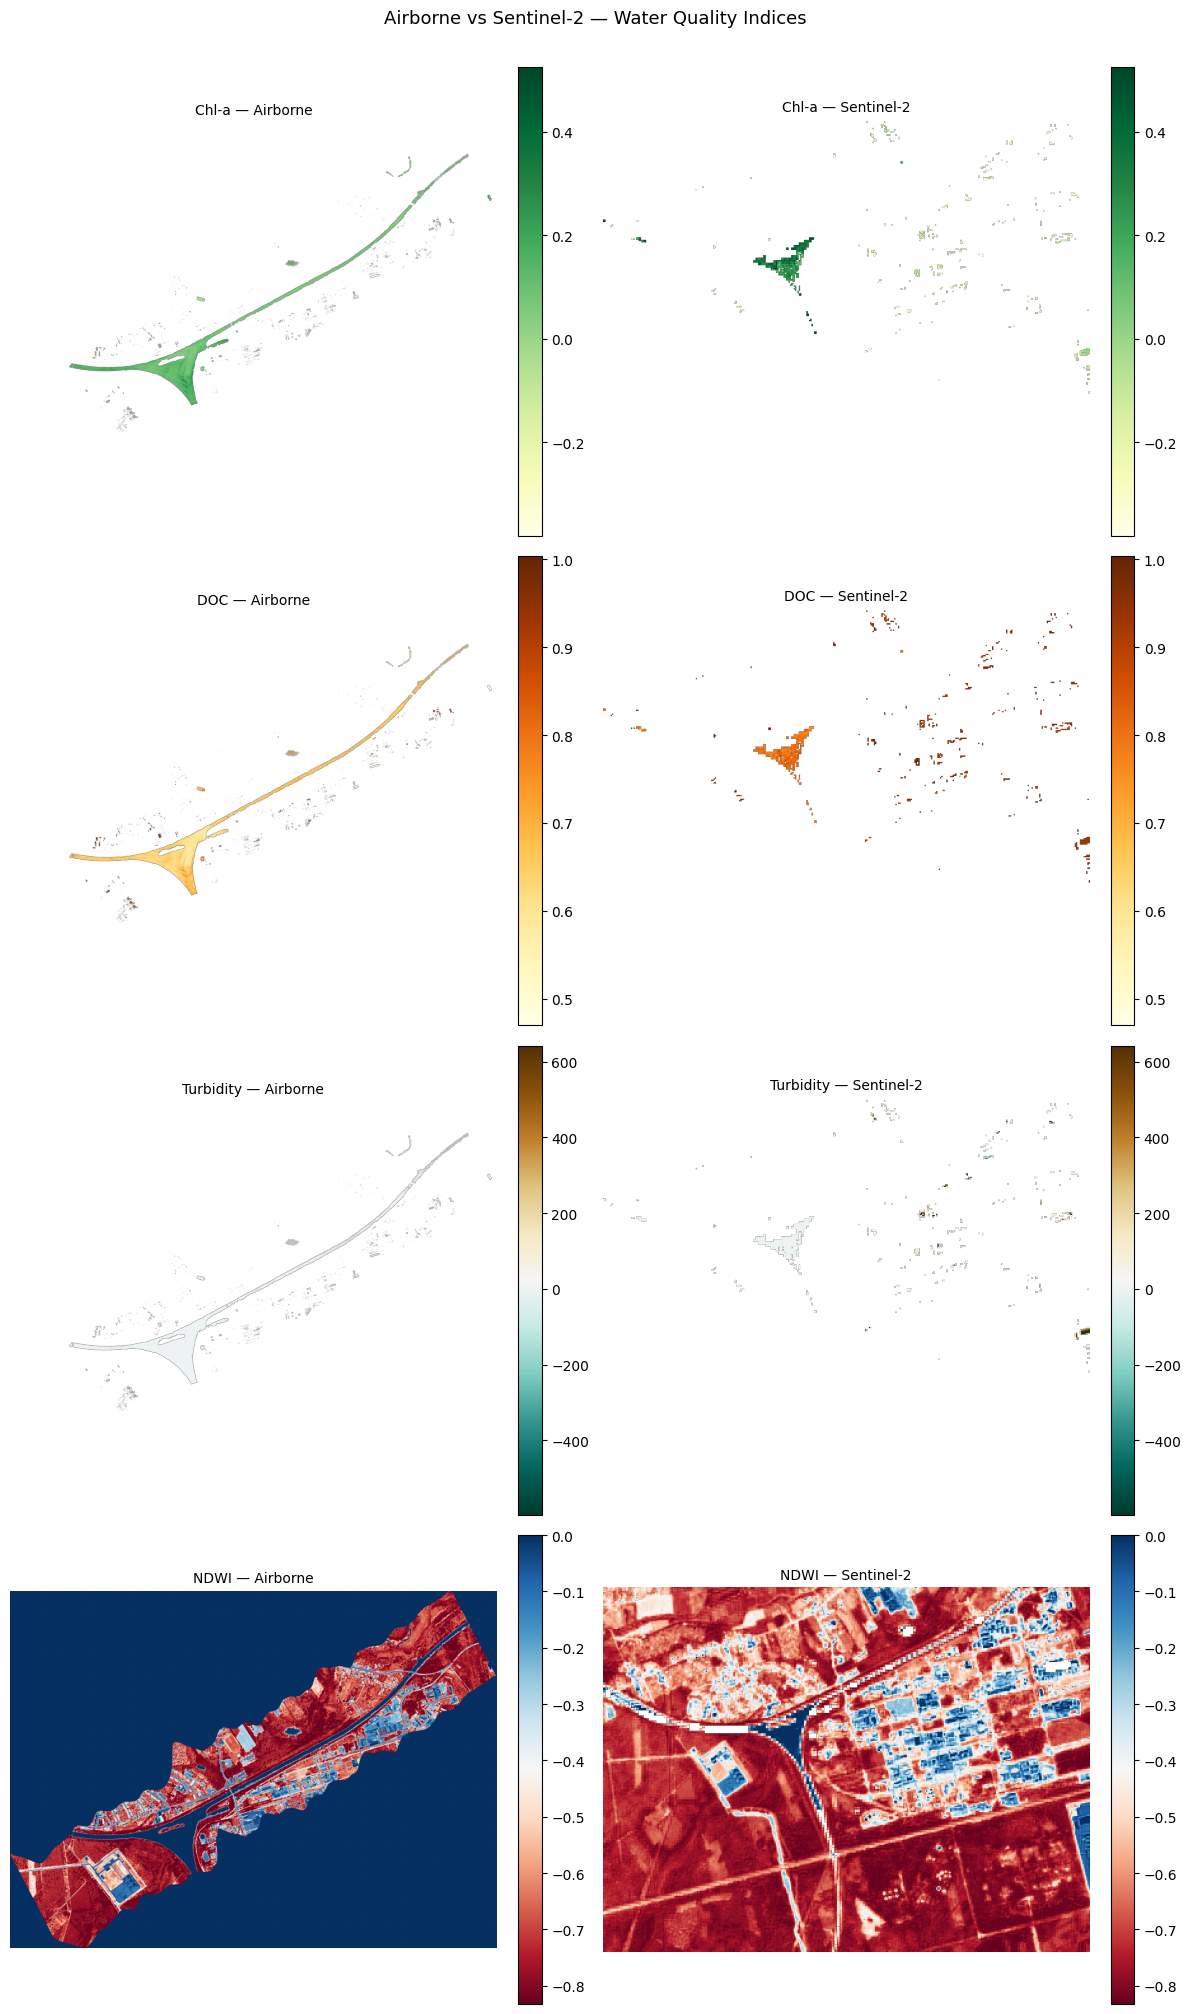

Saved -> comparison_maps.png


In [21]:
compare = [
    ('Chl-a',     chla_air_w, chla_s2_w, 'YlGn'),
    ('DOC',       doc_air_w,  doc_s2_w,  'YlOrBr'),
    ('Turbidity', turb_air_w, turb_s2_w, 'BrBG_r'),
    ('NDWI',      ndwi_air,   ndwi_s2,   'RdBu'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for row, (name, arr_a, arr_s, cmap) in enumerate(compare):
    vmin = min(np.nanpercentile(arr_a, 2), np.nanpercentile(arr_s, 2))
    vmax = max(np.nanpercentile(arr_a, 98), np.nanpercentile(arr_s, 98))
    for col, (arr, lbl) in enumerate([(arr_a, 'Airborne'), (arr_s, 'Sentinel-2')]):
        ax = axes[row, col]
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f'{name} — {lbl}', fontsize=10); ax.axis('off')
plt.suptitle('Airborne vs Sentinel-2 — Water Quality Indices', fontsize=13, y=1.005)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/comparison_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> comparison_maps.png')

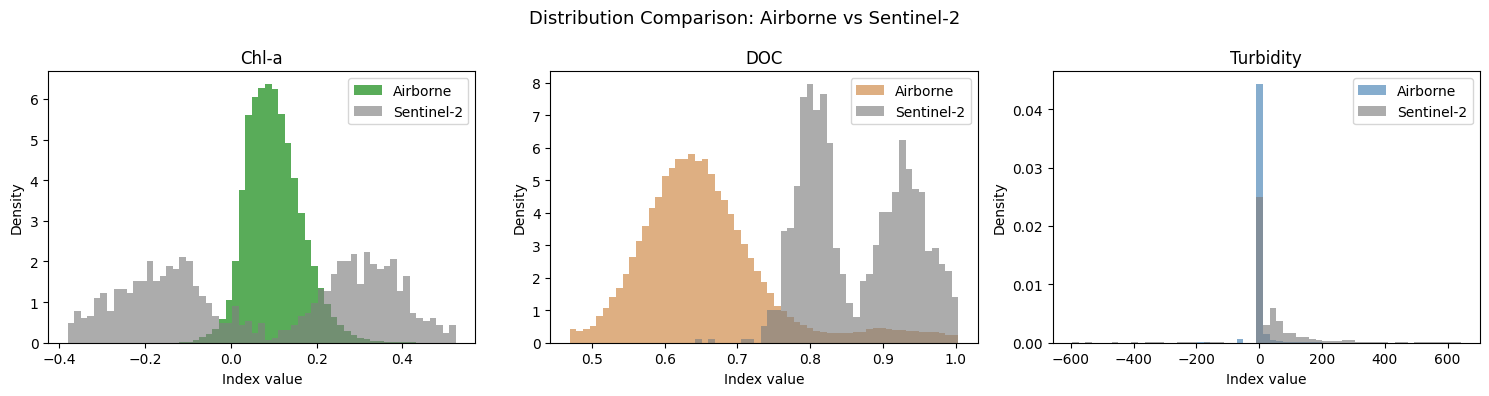

Saved -> comparison_histograms.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, arr_a, arr_s, col) in zip(axes, [
    ('Chl-a',     chla_air_w, chla_s2_w, 'green'),
    ('DOC',       doc_air_w,  doc_s2_w,  'peru'),
    ('Turbidity', turb_air_w, turb_s2_w, 'steelblue'),
]):
    va = arr_a[np.isfinite(arr_a)].flatten()
    vs = arr_s[np.isfinite(arr_s)].flatten()
    lo = min(np.nanpercentile(va, 2),  np.nanpercentile(vs, 2))
    hi = max(np.nanpercentile(va, 98), np.nanpercentile(vs, 98))
    bins = np.linspace(lo, hi, 60)
    ax.hist(va, bins=bins, density=True, alpha=0.65, color=col,    label='Airborne')
    ax.hist(vs, bins=bins, density=True, alpha=0.65, color='grey', label='Sentinel-2')
    ax.set_title(name); ax.set_xlabel('Index value')
    ax.set_ylabel('Density'); ax.legend()
plt.suptitle('Distribution Comparison: Airborne vs Sentinel-2', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/comparison_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> comparison_histograms.png')

In [23]:
rows = []
for name, arr_a, arr_s, _ in compare:
    for label, arr in [('Airborne', arr_a), ('Sentinel-2', arr_s)]:
        v = arr[np.isfinite(arr)].flatten()
        rows.append({'Index': name, 'Source': label,
                     'Mean':   round(float(np.nanmean(v)), 5),
                     'Median': round(float(np.nanmedian(v)), 5),
                     'Std':    round(float(np.nanstd(v)), 5),
                     'P5':     round(float(np.nanpercentile(v, 5)), 5),
                     'P95':    round(float(np.nanpercentile(v, 95)), 5)})
stats_df = pd.DataFrame(rows)
stats_df.to_csv(f'{OUTPUT_DIR}/index_statistics.csv', index=False)
print('Saved -> index_statistics.csv')
stats_df

Saved -> index_statistics.csv


,Index,Source,Mean,Median,Std,P5,P95
0,Chl-a,Airborne,0.08090,0.09428,0.20168,0.00322,0.21203
1,Chl-a,Sentinel-2,0.07018,0.05625,0.27311,-0.32965,0.45568
2,DOC,Airborne,0.65695,0.64255,0.11130,0.52282,0.89390
3,DOC,Sentinel-2,0.86746,0.85250,0.07485,0.76706,0.98662
4,Turbidity,Airborne,0.30208,1.29971,1119.04895,1.15257,15.66520
5,Turbidity,Sentinel-2,2.58237,3.81204,1196.24854,1.61356,289.94174
6,NDWI,Airborne,-0.16243,0.00000,0.30159,-0.80169,0.00000
7,NDWI,Sentinel-2,-0.63372,-0.71036,0.19651,-0.81585,-0.19850


---
## 10. Output Summary

In [24]:
print('=' * 55)
print('ANALYSIS COMPLETE')
print('=' * 55)
print(f'Airborne flight date   : {AIRBORNE_DATE}')
print(f'Sentinel-2 window      : {d_from}  to  {d_to}')
print()
print('Output files:')
for f in sorted(Path(OUTPUT_DIR).glob('*')):
    print(f'  {f.name:<45}  {f.stat().st_size / 1024:>8.1f} KB')

ANALYSIS COMPLETE
Airborne flight date   : 2025-06-17
Sentinel-2 window      : 2025-06-12  to  2025-06-22

Output files:
  chla_airborne.tif                               42830.9 KB
  chla_s2.tif                                       430.1 KB
  comparison_histograms.png                          48.5 KB
  comparison_maps.png                              1522.8 KB
  doc_airborne.tif                                42830.9 KB
  doc_s2.tif                                        430.1 KB
  false_colour_airborne.png                        1270.6 KB
  false_colour_s2.png                              2267.6 KB
  index_statistics.csv                                0.5 KB
  ndwi_airborne.tif                               42830.9 KB
  ndwi_s2.tif                                       430.1 KB
  spectral_heatmap.png                              100.2 KB
  spectral_library.png                              227.6 KB
  turb_airborne.tif                               42830.9 KB
  turb_s2.tif            

In [25]:
@dataclass
class SAMResult:
    class_map:   np.ndarray
    angle_map:   np.ndarray
    all_angles:  np.ndarray
    class_names: list[str]

    def area_stats(self, pixel_area_m2: float = 1.0) -> pd.DataFrame:
        rows = []
        for i, cls in enumerate(self.class_names):
            count = int(np.sum(self.class_map == i))
            rows.append({"Class": cls, "Pixels": count,
                         "Area_km2": round(count * pixel_area_m2 / 1e6, 6)})
        unclass = int(np.sum(self.class_map == -1))
        rows.append({"Class": "unclassified", "Pixels": unclass,
                     "Area_km2": round(unclass * pixel_area_m2 / 1e6, 6)})
        return pd.DataFrame(rows)


def resample_library(
    lib_wl: np.ndarray,
    lib_spectra: np.ndarray,
    target_wl: np.ndarray,
) -> np.ndarray:
    indices = np.array([np.argmin(np.abs(lib_wl - w)) for w in target_wl])
    return lib_spectra[:, indices]


def compute_angles(
    pixels: np.ndarray,
    references: np.ndarray,
) -> np.ndarray:
    pix_norm = np.linalg.norm(pixels,     axis=1, keepdims=True) 
    ref_norm = np.linalg.norm(references, axis=1, keepdims=True).T 
    dot      = pixels @ references.T
    cos_sim  = np.clip(dot / (pix_norm * ref_norm + 1e-10), -1.0, 1.0)
    return np.arccos(cos_sim)


def classify(
    image: np.ndarray,
    references: np.ndarray,
    class_names: list[str],
    threshold_rad: Optional[float] = None,
) -> SAMResult:
    rows, cols, bands = image.shape
    pixels  = image.reshape(-1, bands).astype(np.float64)

    angles      = compute_angles(pixels, references.astype(np.float64))
    class_flat  = np.argmin(angles, axis=1)
    angle_flat  = np.min(angles,    axis=1)

    if threshold_rad is not None:
        class_flat = np.where(angle_flat > threshold_rad, -1, class_flat)

    return SAMResult(
        class_map   = class_flat.reshape(rows, cols).astype(np.int16),
        angle_map   = angle_flat.reshape(rows, cols),
        all_angles  = angles.reshape(rows, cols, -1),
        class_names = class_names,
    )


def from_csv(
    csv_path: str,
    wl_col: str = "Wavelength",
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    df          = pd.read_csv(csv_path)
    class_names = [c for c in df.columns if c != wl_col]
    lib_wl      = df[wl_col].values.astype(float)
    lib_spectra = np.stack([df[c].values.astype(float) for c in class_names])
    return lib_wl, lib_spectra, class_names

In [51]:
import spectral.io.envi as envi

img     = envi.open(HDR_FILE, BSQ_FILE)
cube_wl = np.array(img.metadata['wavelength'], dtype=float)
nrows, ncols, nbands = img.nrows, img.ncols, img.nbands

lib_wl, lib_spectra, class_names = from_csv(SPECTRAL_LIBRARY_CSV)
ref_air   = resample_library(lib_wl, lib_spectra, cube_wl).astype(np.float64)
ref_norms = np.linalg.norm(ref_air, axis=1, keepdims=True)
ref_air_n = ref_air / ref_norms

CHUNK = 256
class_map = np.empty((nrows, ncols), dtype=np.int16)
angle_map = np.empty((nrows, ncols), dtype=np.float32)


THRESHOLD = np.radians(35)

VALID_NORM_THRESHOLD = 0.003

def compute_indices(chunk: np.ndarray, cube_wl: np.ndarray) -> dict:
    def b(nm):
        return chunk.reshape(-1, chunk.shape[2])[:, np.argmin(np.abs(cube_wl - nm))]
    g    = b(560);  nir  = b(865)
    r    = b(665);  r700 = b(700)
    b443 = b(443)
    ndwi = (g    - nir)  / (g    + nir  + 1e-10)
    chla = (r700 - r)    / (r700 + r    + 1e-10)
    doc  = (b443 - r)    / (b443 + r    + 1e-10)
    turb = (r    - b443) / (r    + b443 + 1e-10)
    return {'ndwi': ndwi, 'chla': chla, 'doc': doc, 'turb': turb}

NDWI_WATER = 0.1
CHLA_WATER = 0.2
DOC_WATER  = 0.3
TURB_WATER = 0.1
WATER_IDX  = class_names.index('water')

for row_start in range(0, nrows, CHUNK):
    row_end = min(row_start + CHUNK, nrows)
    chunk   = img.read_subregion((row_start, row_end), (0, ncols)).astype(np.float64)
    chunk   = np.clip(chunk, 0, None)

    pixels    = chunk.reshape(-1, nbands)
    pix_norms = np.linalg.norm(pixels, axis=1, keepdims=True)
    valid     = pix_norms.flatten() > VALID_NORM_THRESHOLD

    pixels_n = np.zeros_like(pixels)
    pixels_n[valid] = pixels[valid] / pix_norms[valid]

    angles     = np.full((pixels.shape[0], len(class_names)), np.pi / 2)
    angles[valid] = compute_angles(pixels_n[valid], ref_air_n)
    class_flat = np.argmin(angles, axis=1)
    angle_flat = np.min(angles,    axis=1)

    class_flat = np.where(~valid | (angle_flat > THRESHOLD), -1, class_flat)

    idx = compute_indices(chunk, cube_wl)
    is_water = (
        (idx['ndwi'] > NDWI_WATER) &
        ((idx['chla'] > CHLA_WATER) | (idx['turb'] > TURB_WATER))
    ) 

    class_flat = np.where(is_water, WATER_IDX, class_flat)

    class_map[row_start:row_end] = class_flat.reshape(row_end - row_start, ncols)
    angle_map[row_start:row_end] = angle_flat.reshape(row_end - row_start, ncols)
    print(f'Processed rows {row_start}–{row_end}')

result = SAMResult(class_map=class_map, angle_map=angle_map,
                   all_angles=None, class_names=class_names)
print(result.area_stats())

Processed rows 0–256
Processed rows 256–512
Processed rows 512–768
Processed rows 768–1024
Processed rows 1024–1280
Processed rows 1280–1536
Processed rows 1536–1792
Processed rows 1792–2048
Processed rows 2048–2304
Processed rows 2304–2560
Processed rows 2560–2816
Processed rows 2816–2838
          Class   Pixels  Area_km2
0     buildings   241993  0.241993
1        forest   389378  0.389378
2         field   336624  0.336624
3         grass  1778444  1.778444
4         water   215357  0.215357
5  unclassified  7998560  7.998560
